## 🐱 vs 🐶 Cats vs Dogs — Classical ML Comparison

**Algorithms compared:** Logistic Regression · SVM (RBF) · K-Nearest Neighbors · Random Forest · Gradient Boosting

**Features used:** HOG (Histogram of Oriented Gradients) + Color Histograms

**Dataset:** 2,000 images (1,000 cats + 1,000 dogs) — fast & balanced

## 1. Install & Import Dependencies

In [1]:
!pip install tensorflow-datasets scikit-image scikit-learn matplotlib seaborn --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow_datasets as tfds
from skimage.feature import hog
from skimage.transform import resize

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score
)

np.random.seed(42)
print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Load Dataset (2,000 Images — Fast & Balanced)

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE    = 64      # resize all images to 64x64 (small = fast features)
PER_CLASS   = 1000    # 1000 cats + 1000 dogs = 2000 total
CLASS_NAMES = ['cat', 'dog']

# Load dataset
full_ds, info = tfds.load(
    'cats_vs_dogs',
    split='train',
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
)

print(f'Full dataset : {info.splits["train"].num_examples:,} images')
print(f'Using subset : {PER_CLASS * 2:,} images  ({PER_CLASS:,} cats + {PER_CLASS:,} dogs)')
print(f'Image size   : {IMG_SIZE}x{IMG_SIZE}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.U3PJAC_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Full dataset : 23,262 images
Using subset : 2,000 images  (1,000 cats + 1,000 dogs)
Image size   : 64x64


## 3. Feature Extraction (HOG + Color Histograms)

In [4]:
def extract_features(image_np):
    """Extract HOG + color histogram features from a single image (numpy array)."""
    img = resize(image_np, (IMG_SIZE, IMG_SIZE), anti_aliasing=True)

    # HOG features — captures shape/texture
    hog_feats = hog(
        img,
        orientations=8,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        channel_axis=-1
    )

    # Color histograms per channel — captures color distribution
    color_feats = []
    for ch in range(3):
        hist, _ = np.histogram(img[:, :, ch], bins=32, range=(0, 1))
        color_feats.append(hist)
    color_feats = np.concatenate(color_feats)

    return np.concatenate([hog_feats, color_feats])


def collect_images(dataset, per_class=PER_CLASS):
    """Filter balanced subset from the TFDS dataset and extract features."""
    cats, dogs = [], []
    for img, label in dataset:
        img_np = img.numpy().astype(np.float32) / 255.0
        if label.numpy() == 0 and len(cats) < per_class:
            cats.append((img_np, 0))
        elif label.numpy() == 1 and len(dogs) < per_class:
            dogs.append((img_np, 1))
        if len(cats) == per_class and len(dogs) == per_class:
            break
    return cats + dogs


print('⏳ Collecting images...')
t0 = time.time()
samples = collect_images(full_ds)
print(f'   Collected {len(samples):,} images in {time.time()-t0:.1f}s')

print('⏳ Extracting features...')
t0 = time.time()
X = np.array([extract_features(img) for img, _ in samples])
y = np.array([label for _, label in samples])

print(f'   Feature matrix : {X.shape}  ({X.shape[1]} features per image)')
print(f'   Labels         : {np.bincount(y)} (cats=0, dogs=1)')
print(f'   Extraction time: {time.time()-t0:.1f}s')

⏳ Collecting images...
   Collected 2,000 images in 20.7s
⏳ Extracting features...
   Feature matrix : (2000, 1664)  (1664 features per image)
   Labels         : [1000 1000] (cats=0, dogs=1)
   Extraction time: 46.1s


## 4. Explore the Data

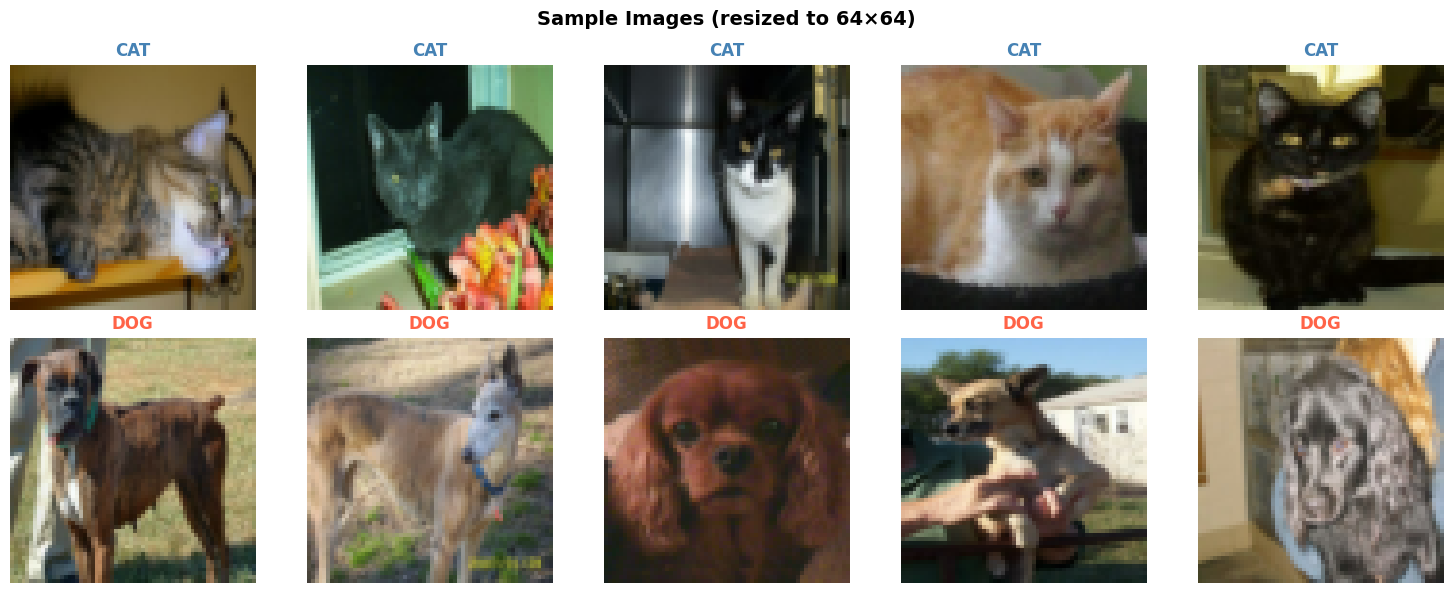

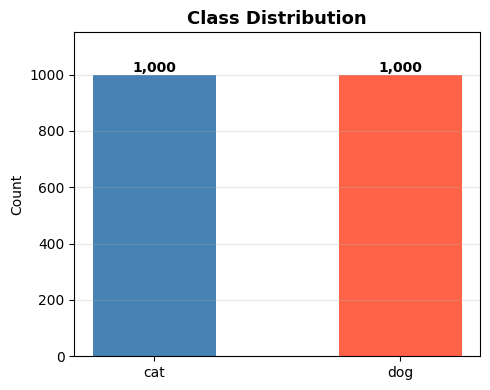

In [5]:
# Show sample images
palette = {'cat': 'steelblue', 'dog': 'tomato'}
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img, label = samples[i * (PER_CLASS // 5)]
    name = CLASS_NAMES[label]
    ax.imshow(resize(img, (IMG_SIZE, IMG_SIZE), anti_aliasing=True))
    ax.set_title(name.upper(), fontsize=12, fontweight='bold', color=palette[name])
    ax.axis('off')
plt.suptitle('Sample Images (resized to 64×64)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Class distribution
counts = np.bincount(y)
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(CLASS_NAMES, counts, color=['steelblue', 'tomato'], width=0.5)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split

In [6]:
from sklearn.model_selection import train_test_split

# Shuffle before splitting
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train
)  # 0.125 x 0.80 = 0.10 of total

print(f'Train      : {len(X_train):,} samples')
print(f'Validation : {len(X_val):,} samples')
print(f'Test       : {len(X_test):,} samples')
print(f'Features   : {X_train.shape[1]:,} per sample')

Train      : 1,400 samples
Validation : 200 samples
Test       : 400 samples
Features   : 1,664 per sample


## 6. Define & Train All Classifiers

In [7]:
# Each model is wrapped in a Pipeline with StandardScaler for fair comparison
classifiers = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42))
    ]),
    'K-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                            max_depth=4, random_state=42))
    ]),
}

results = {}   # store metrics per model

print(f"{'Model':<25} {'Train Acc':>10} {'Val Acc':>10} {'Test Acc':>10} {'Time':>8}")
print('-' * 68)

for name, pipe in classifiers.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - t0

    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    val_acc   = accuracy_score(y_val,   pipe.predict(X_val))
    y_pred    = pipe.predict(X_test)
    y_prob    = pipe.predict_proba(X_test)[:, 1]
    test_acc  = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc   = auc(fpr, tpr)

    results[name] = {
        'train_acc': train_acc, 'val_acc': val_acc,
        'test_acc': test_acc, 'roc_auc': roc_auc,
        'y_pred': y_pred, 'y_prob': y_prob,
        'fpr': fpr, 'tpr': tpr, 'time': elapsed
    }
    print(f"{name:<25} {train_acc:>10.4f} {val_acc:>10.4f} {test_acc:>10.4f} {elapsed:>7.1f}s")

print('-' * 68)
best_name = max(results, key=lambda k: results[k]['test_acc'])
print(f"\n🏆 Best model: {best_name}  (Test Acc = {results[best_name]['test_acc']:.4f})")

Model                      Train Acc    Val Acc   Test Acc     Time
--------------------------------------------------------------------
Logistic Regression           1.0000     0.7050     0.6575     0.8s
SVM (RBF)                     1.0000     0.7800     0.7100    15.4s
K-Nearest Neighbors           0.6571     0.6600     0.5850     0.0s
Random Forest                 1.0000     0.7550     0.7550     9.6s
Gradient Boosting             1.0000     0.7550     0.7250   280.4s
--------------------------------------------------------------------

🏆 Best model: Random Forest  (Test Acc = 0.7550)


## 7. Compare Models — Accuracy & AUC Bar Chart

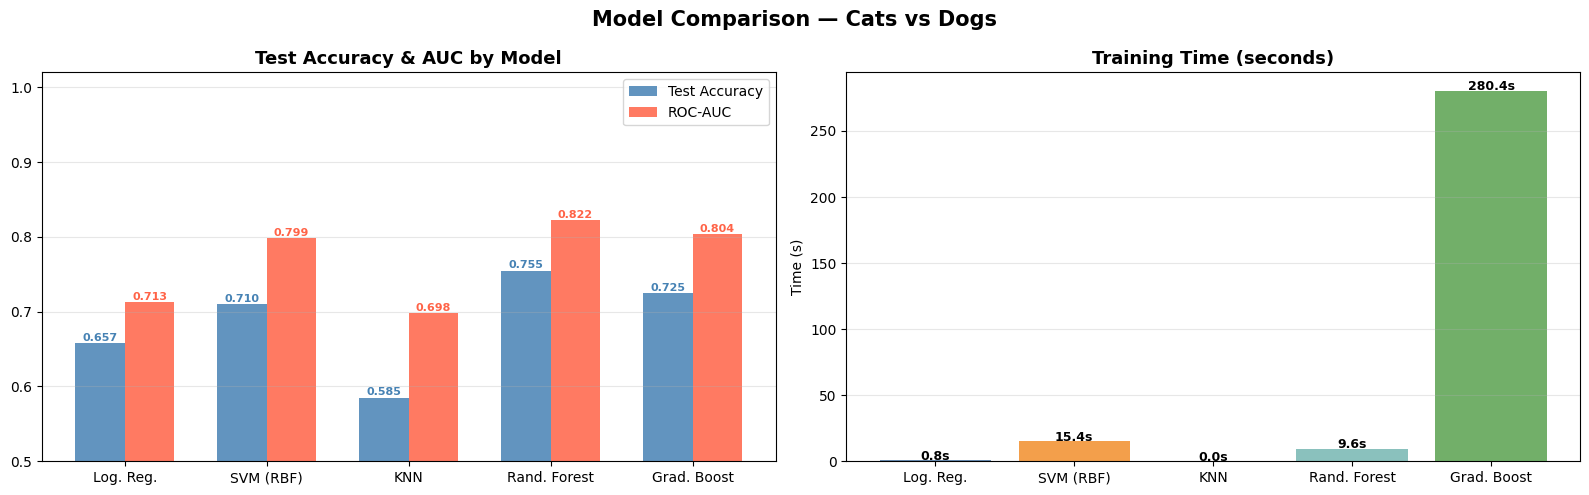

In [8]:
names  = list(results.keys())
short_names = ['Log. Reg.', 'SVM (RBF)', 'KNN', 'Rand. Forest', 'Grad. Boost']
accs   = [results[n]['test_acc'] for n in names]
aucs   = [results[n]['roc_auc']  for n in names]
times  = [results[n]['time']     for n in names]

x = np.arange(len(names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy & AUC grouped bar chart
bars1 = axes[0].bar(x - width/2, accs, width, label='Test Accuracy', color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + width/2, aucs, width, label='ROC-AUC',       color='tomato',    alpha=0.85)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold', color='steelblue')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold', color='tomato')
axes[0].set_xticks(x); axes[0].set_xticklabels(short_names, fontsize=10)
axes[0].set_ylim(0.5, 1.02)
axes[0].set_title('Test Accuracy & AUC by Model', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Training time bar chart
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']
bars3 = axes[1].bar(short_names, times, color=colors, alpha=0.85)
for bar, t in zip(bars3, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{t:.1f}s', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Training Time (seconds)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Time (s)'); axes[1].grid(axis='y', alpha=0.3)
plt.setp(axes[1].get_xticklabels(), fontsize=10)

plt.suptitle('Model Comparison — Cats vs Dogs', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. ROC Curves — All Models Overlaid

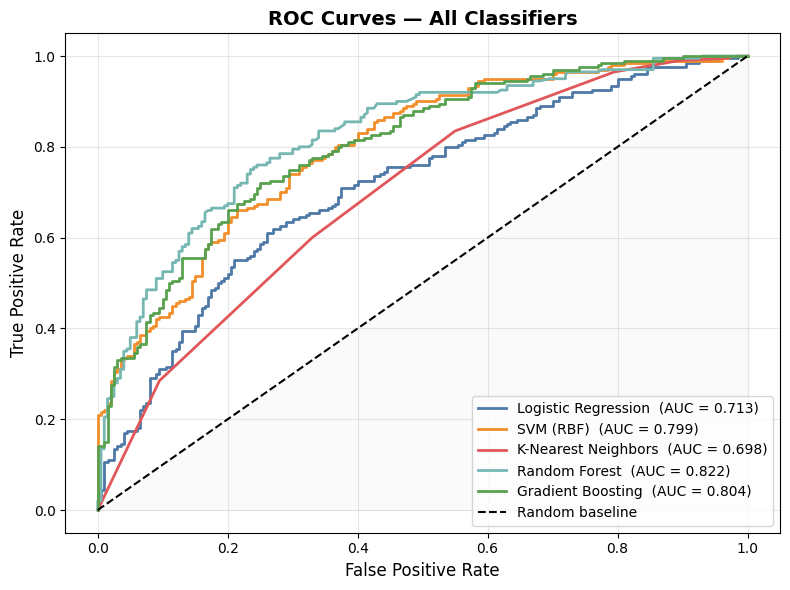

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']

for (name, res), color in zip(results.items(), colors):
    ax.plot(res['fpr'], res['tpr'], lw=2, color=color,
            label=f"{name}  (AUC = {res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random baseline')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Classifiers', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Confusion Matrices — All Models

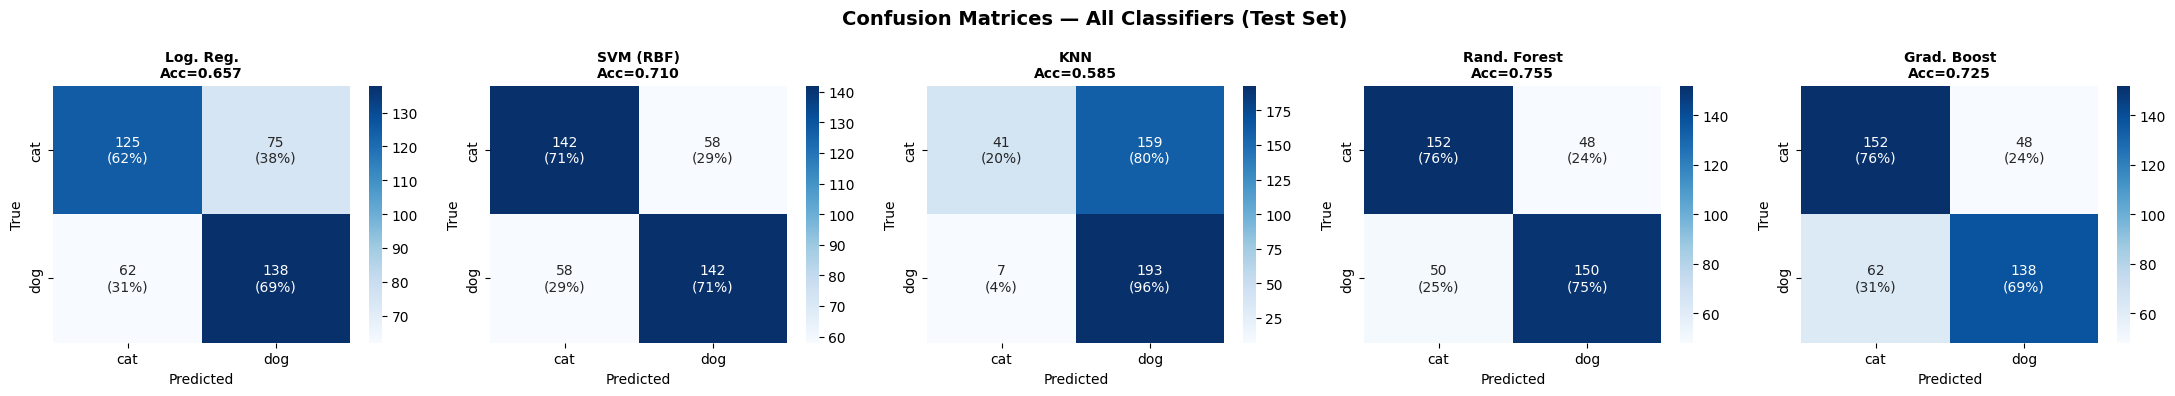

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, res), short in zip(axes, results.items(), short_names):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f'{v}\n({p:.0f}%)' for v, p in zip(rv, rp)]
                       for rv, rp in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={'size': 10})
    ax.set_title(f'{short}\nAcc={res["test_acc"]:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — All Classifiers (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Detailed Classification Report (Best Model)

In [11]:
best_res = results[best_name]

print(f'\n{'='*50}')
print(f'  BEST MODEL: {best_name}')
print(f'{'='*50}')
print(f'  Test Accuracy : {best_res["test_acc"]:.4f}')
print(f'  ROC-AUC       : {best_res["roc_auc"]:.4f}')
print(f'  Training Time : {best_res["time"]:.1f}s')
print(f'{'='*50}\n')
print('Classification Report:')
print(classification_report(y_test, best_res['y_pred'], target_names=CLASS_NAMES))


  BEST MODEL: Random Forest
  Test Accuracy : 0.7550
  ROC-AUC       : 0.8225
  Training Time : 9.6s

Classification Report:
              precision    recall  f1-score   support

         cat       0.75      0.76      0.76       200
         dog       0.76      0.75      0.75       200

    accuracy                           0.76       400
   macro avg       0.76      0.76      0.75       400
weighted avg       0.76      0.76      0.75       400



## 11. Summary Comparison Table

In [12]:
import pandas as pd

summary = pd.DataFrame([
    {
        'Model': name,
        'Train Acc': f"{res['train_acc']:.4f}",
        'Val Acc':   f"{res['val_acc']:.4f}",
        'Test Acc':  f"{res['test_acc']:.4f}",
        'ROC-AUC':   f"{res['roc_auc']:.4f}",
        'Time (s)':  f"{res['time']:.1f}",
    }
    for name, res in results.items()
])
summary = summary.sort_values('Test Acc', ascending=False).reset_index(drop=True)
summary.index += 1  # rank from 1
print('\n=== FINAL LEADERBOARD ===')
print(summary.to_string())


=== FINAL LEADERBOARD ===
                 Model Train Acc Val Acc Test Acc ROC-AUC Time (s)
1        Random Forest    1.0000  0.7550   0.7550  0.8225      9.6
2    Gradient Boosting    1.0000  0.7550   0.7250  0.8036    280.4
3            SVM (RBF)    1.0000  0.7800   0.7100  0.7986     15.4
4  Logistic Regression    1.0000  0.7050   0.6575  0.7126      0.8
5  K-Nearest Neighbors    0.6571  0.6600   0.5850  0.6980      0.0


## 12. Visualize Predictions (Best Model)

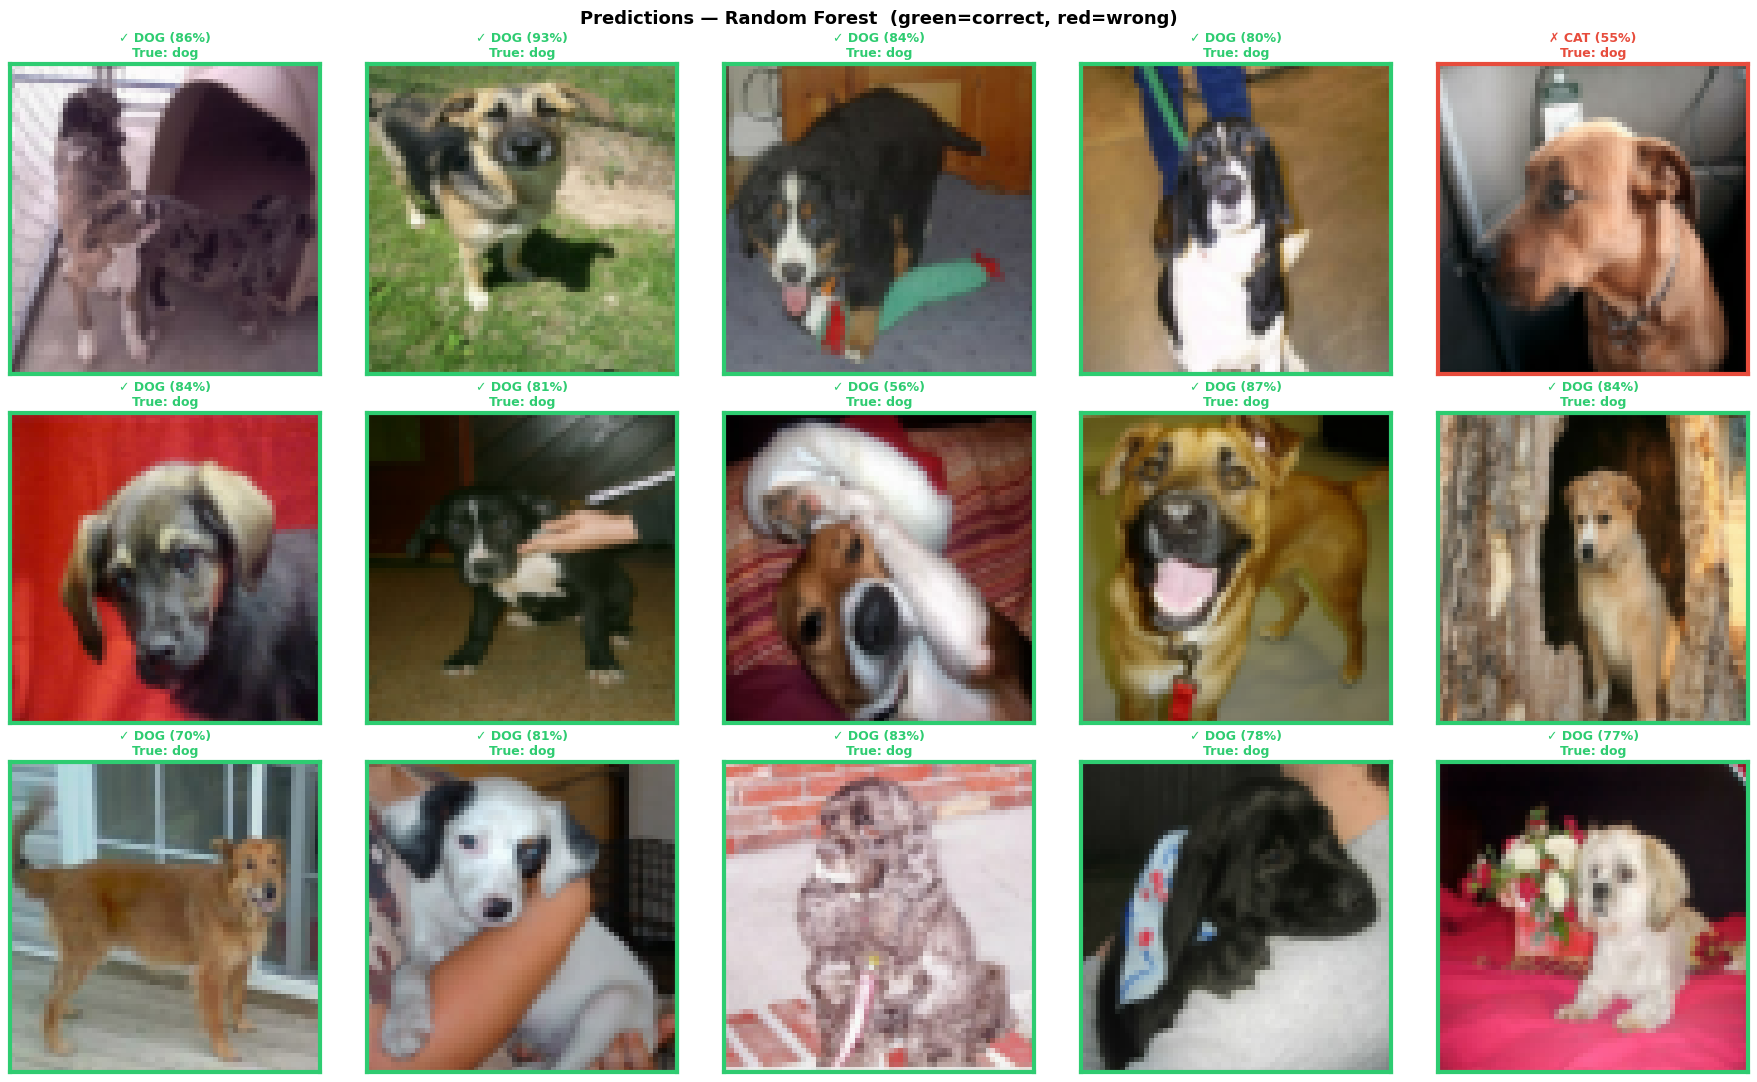

In [13]:
best_pipe = classifiers[best_name]

# Get test samples (keep original images for display)
test_indices = np.where(np.isin(np.arange(len(y)), np.arange(len(X_test))))[0][:15]
# Use the last 15 images from our samples list for display
display_samples = samples[-15:]
display_X = np.array([extract_features(img) for img, _ in display_samples])
display_y = np.array([lbl for _, lbl in display_samples])
preds     = best_pipe.predict(display_X)
probs     = best_pipe.predict_proba(display_X)[:, 1]

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
for i, ax in enumerate(axes.flat):
    img, true_lbl = display_samples[i]
    pred_lbl  = preds[i]
    prob      = probs[i]
    conf      = prob if pred_lbl == 1 else 1 - prob
    correct   = true_lbl == pred_lbl
    color     = '#2ecc71' if correct else '#e74c3c'
    true_name = CLASS_NAMES[true_lbl]
    pred_name = CLASS_NAMES[pred_lbl]

    ax.imshow(resize(img, (IMG_SIZE, IMG_SIZE), anti_aliasing=True))
    ax.set_title(f"{'✓' if correct else '✗'} {pred_name.upper()} ({conf:.0%})\nTrue: {true_name}",
                 color=color, fontsize=9, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f'Predictions — {best_name}  (green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Predict on Any Custom Image

In [14]:
def predict_image(path_or_url, model_name=None):
    """Predict cat vs dog for a local file or URL using any trained model."""
    import requests
    from io import BytesIO
    from PIL import Image as PILImage

    pipe = classifiers[model_name] if model_name else classifiers[best_name]
    used_name = model_name or best_name

    if str(path_or_url).startswith('http'):
        resp = requests.get(path_or_url, timeout=10)
        img_pil = PILImage.open(BytesIO(resp.content)).convert('RGB')
    else:
        img_pil = PILImage.open(path_or_url).convert('RGB')

    img_np = np.array(img_pil, dtype=np.float32) / 255.0
    feats  = extract_features(img_np).reshape(1, -1)
    prob   = float(pipe.predict_proba(feats)[0][1])
    label  = 'Dog 🐶' if prob > 0.5 else 'Cat 🐱'
    conf   = prob if prob > 0.5 else 1 - prob

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_pil.resize((IMG_SIZE * 2, IMG_SIZE * 2)))
    axes[0].axis('off')
    axes[0].set_title(f'{label}  —  {conf:.1%} confidence\n[{used_name}]',
                      fontsize=12, fontweight='bold')
    axes[1].barh(['Cat 🐱', 'Dog 🐶'], [1-prob, prob],
                  color=['steelblue', 'tomato'], height=0.5)
    for i, val in enumerate([1-prob, prob]):
        axes[1].text(val + 0.01, i, f'{val:.1%}', va='center', fontsize=11)
    axes[1].set_xlim(0, 1.15)
    axes[1].set_title('Probabilities'); axes[1].grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()
    return label, conf

# Examples:
# predict_image('my_cat.jpg')
# predict_image('https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/480px-Cat03.jpg')
# predict_image('my_dog.jpg', model_name='SVM (RBF)')
print('predict_image() ready!  Use any model name from:', list(classifiers.keys()))

predict_image() ready!  Use any model name from: ['Logistic Regression', 'SVM (RBF)', 'K-Nearest Neighbors', 'Random Forest', 'Gradient Boosting']
